In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('ushape.csv',header=None)

In [21]:
df.head()

,0,1,2
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [22]:
df.columns = ['X', 'Y', 'class']

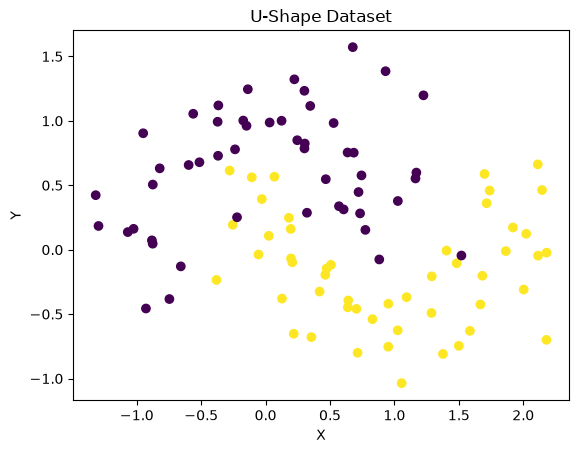

In [23]:
# plt.scatter(df['X'],df['Y'],c=df['class'])

plt.scatter(
    df['X'],
    df['Y'],
    c=df['class']
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('U-Shape Dataset')
plt.show()

In [24]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [25]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [26]:
model = Sequential()

model.add(Dense(2,activation='sigmoid',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Set parameters to 0
model.get_weights()

[array([[ 0.4053229,  0.6475558],
        [-0.5666029,  0.350708 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.2568884 ],
        [ 0.49274385]], dtype=float32),
 array([0.], dtype=float32)]

In [28]:
initial_weights = model.get_weights()

In [29]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [30]:
model.set_weights(initial_weights)

In [31]:
model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [32]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [33]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.5000 - loss: 0.8636 - val_accuracy: 0.5000 - val_loss: 0.8362
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5000 - loss: 0.8613 - val_accuracy: 0.5000 - val_loss: 0.8342
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5000 - loss: 0.8591 - val_accuracy: 0.5000 - val_loss: 0.8322
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5000 - loss: 0.8572 - val_accuracy: 0.5000 - val_loss: 0.8302
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5000 - loss: 0.8550 - val_accuracy: 0.5000 - val_loss: 0.8281
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.8529 - val_accuracy: 0.5000 - val_loss: 0.8261
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 0.8507 - val_accuracy: 0.5000 - val_loss: 0.8241
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - loss: 0.8487 - val_accuracy: 0.5000 - val_loss

In [34]:
model.get_weights()

[array([[0.7009089 , 0.7009089 ],
        [0.24357283, 0.24357283]], dtype=float32),
 array([0.27542603, 0.27542603], dtype=float32),
 array([[0.26858667],
        [0.26858667]], dtype=float32),
 array([0.25437185], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

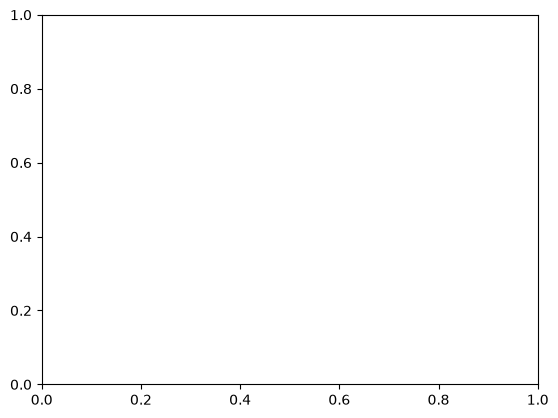

In [35]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)